In [8]:
#Bloco de Processamento de Dados
!pip install matplotlib pandas numpy
!pip install seaborn
!pip install pyod
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Lendo o CSV
df = pd.read_csv('Data_Cacak.csv')
df.head()


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\ruanr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\ruanr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/169.7 kB ? eta -:--:--
     -- ------------------------------------- 10.2/169.7 kB ? eta -:--:--
     -- ------------------------------------- 10.2/169.7 kB ? eta -:--:--
     -- ------------------------------------- 10.2/169.7 kB ? eta -:--:--
     -- ------------------------------------- 10.2/169.7 kB ? eta -:--:--
     -------------------- ---------------- 92.2/169.7 kB 403.5 kB/s eta 0:00:01
     ----------------------- ------------ 112.6/169.7 kB 435.7 kB/s eta 0:00:01
     ---------------------------------- - 163.8/169.7 kB 517.2 kB/s eta 0:00:01
     ------------------------------------ 169.7/169.7 kB 509.3 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished 


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\ruanr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,Datetime,AirTemperature,CloudOpacity,DHI,DNI,EBH,GHI,Production - Location 1,Production - Location 2,Production - Location 3
0,11/22/2022 14:00,8.7,59,117,0.0,0,117,11.705333,12.694917,16.355417
1,11/22/2022 15:00,8.9,62,62,0.0,0,62,1.309583,8.262333,1.812333
2,11/22/2022 16:00,9.2,57,15,7.0,1,16,0.000000,0.930667,0.000000
3,11/22/2022 17:00,8.9,81,0,0.0,0,0,0.000000,0.000000,0.000000
4,11/22/2022 18:00,8.9,91,0,0.0,0,0,0.000000,0.000000,0.000000


In [9]:
#Definindo as features
df['Datetime'] = pd.to_datetime(df['Datetime']) #Converte a coluna datetime em um formato conhecido como data e hora pelo pandas
df['Hour'] = df['Datetime'].dt.hour #Cria uma coluna chamada Hour que vai ter as horas de 0 até 23 em cada registro
df_limpo = df[(df['Hour'] >= 5) & (df['Hour'] <= 18)]

df_limpo.info()

x = df_limpo.iloc[:,6].to_numpy().reshape(-1, 1)
y = df_limpo.iloc[:,7].to_numpy().reshape(-1, 1)


<class 'pandas.core.frame.DataFrame'>
Index: 4824 entries, 0 to 8273
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Datetime                 4824 non-null   datetime64[ns]
 1   AirTemperature           4824 non-null   float64       
 2   CloudOpacity             4824 non-null   int64         
 3   DHI                      4824 non-null   int64         
 4   DNI                      4824 non-null   float64       
 5   EBH                      4824 non-null   int64         
 6   GHI                      4824 non-null   int64         
 7   Production - Location 1  4824 non-null   float64       
 8   Production - Location 2  4824 non-null   float64       
 9   Production - Location 3  4824 non-null   float64       
 10  Hour                     4824 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(4)
memory usage: 433.4 KB


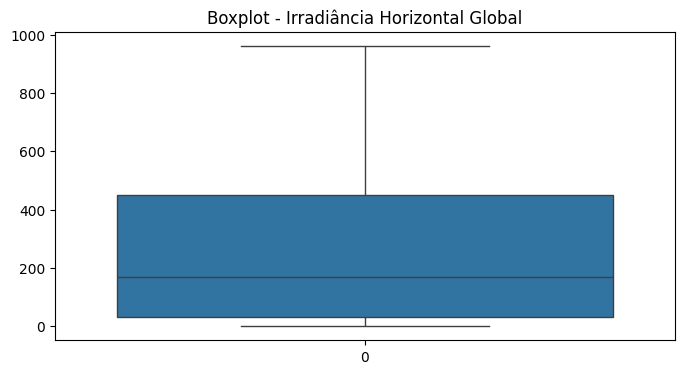

In [10]:
#Implementação do Boxplot para visualização de outliers
import seaborn as seb
plt.figure(figsize=(8, 4))
seb.boxplot(x)
plt.title('Boxplot - Irradiância Horizontal Global')
plt.show()

In [12]:
#Detectando features com possíveis distorções
from pyod.models.knn import KNN
detectar = KNN()
detectar.fit(x)
lista_resultado = detectar.labels_
lista_resultado

array([0, 0, 0, ..., 0, 0, 0], shape=(4824,))

In [13]:
#Separando outliers de dados que vão ser usados no treinamento do modelo
mask = lista_resultado == 0
x_limpo = x[mask]
y_limpo = y[mask]

print(f'X limpo:{x_limpo.shape}, x sujo:{x.shape}')
print(f'Y limpo:{x_limpo.shape}, y sujo:{y.shape}')

X limpo:(4625, 1), x sujo:(4824, 1)
Y limpo:(4625, 1), y sujo:(4824, 1)


In [15]:
#Normalizando os dados
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x_limpo,
    y_limpo,
    test_size=0.25,
    random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
x_normalizado = scaler_x.fit_transform(x_treino)
y_normalizado = scaler_x.fit_transform(y_treino)

print(x_normalizado)
print('\n')
print(y_normalizado)

[[ 0.18283478]
 [-0.4776641 ]
 [-0.97600457]
 ...
 [ 1.3021233 ]
 [-0.70705892]
 [-0.97600457]]


[[ 0.91695489]
 [-0.10532121]
 [-0.86454974]
 ...
 [ 2.08780205]
 [-0.30331593]
 [-0.86554722]]


In [ ]:
#Implementando funções de custo e gradiente descendente
def computar_custo(x, y, w, b):
  m = x.shape[0]

  soma_custo = np.float64(0)

  for i in range(m):
    fwb = w * x[i, 0] + b
    custo = (fwb - y[i, 0]) ** 2
    soma_custo += custo

  total_cost = (1 / (2 * m) * soma_custo)
  return total_cost


def calcular_gradient(x, y, w, b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0

  for i in range(m):
    fwb = w * x[i, 0] + b
    dj_dw_i = (fwb - y[i, 0]) * x[i, 0]
    dj_db_i = (fwb - y[i, 0])

    dj_db += dj_db_i
    dj_dw += dj_dw_i

  dj_db = dj_db / m
  dj_dw = dj_dw / m

  return dj_dw, dj_db

def gradient(x, y, w_inicial, b_inicial, alpha, num_interacao, funcao_custo, funcao_gradient):
  j_historico = []
  p_historico = []

  b = b_inicial
  w = w_inicial

  for i in range(num_interacao):
    dj_dw, dj_db = funcao_gradient(x, y, w, b)

    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    j_historico.append(funcao_custo(x, y, w, b))
    p_historico.append([w, b])

  return w, b,j_historico, p_historico

In [18]:
#Descobrindo os parâmetros w e b
w_inicial = 0
b_inicial = 0
interacao = 10000
alpha = 0.1

w_final, b_final, j_historico, p_historico = gradient(x_normalizado, y_normalizado, w_inicial, b_inicial, alpha, interacao, computar_custo, calcular_gradient)
print(f"Parâmetros finais: w: {w_final}, b: {b_final}")

Parâmetros finais: w: 0.8410865383200685, b: 1.0816511085503465e-16


In [20]:
#Funções de plotagem de dados
def marcadores(x, y, fwb=None, ax=None):
  ax.scatter(x, y, marker='.', c='#FC8D62', label='Dados de Treinamento')
  ax.set_title('Geração de Energia')
  ax.set_xlabel('Irradiância solar')
  ax.set_ylabel('Energia gerada')

  if fwb is not None:
    ax.plot(x, fwb, c='blue', label='Nossa previsão')
  handles, labels = ax.get_legend_handles_labels()
  unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels))
              if l not in labels[:i]]
  ax.legend(*zip(*unique))

def linhas_custo(x, y, w, b, ax):
  for p in zip(x, y):
    fwb_p = w * p[0] + b
    funcao_custo = ((fwb_p - p[1]) **2) / 2
    fc_txt = funcao_custo

    ax.vlines(p[0], p[1], fwb_p, lw=2, color='green', ls='dotted', label='Custo')
    cxy = [p[0], p[1] + (fwb_p - p[1]) / 2]


(3468, 1)


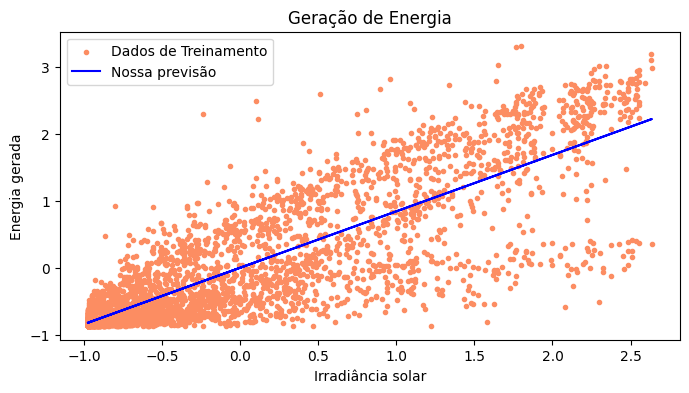

In [21]:
x_usado = x_normalizado.copy()
y_usado = y_normalizado.copy()
f_wb = np.dot(x_usado, w_final) + b_final

fig, ax = plt.subplots(figsize=(8, 4))
#linhas_custo(x_usado, y_usado, w_final, b_final, ax)
marcadores(x_usado, y_usado, f_wb, ax=ax)
print(x_usado.shape)


In [29]:
y_pred = w_final * x_normalizado + b_final

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2 = r2_score(y_normalizado, y_pred)
mae = mean_absolute_error(y_normalizado, y_pred)
rmse = np.sqrt(mean_squared_error(y_normalizado, y_pred))

variancia_y = np.var(y_normalizado)

print(f"R²: {r2:.2f} MAE: {mae:.2f} | RMSE: {rmse:.2f}")


R²: 0.71 MAE: 0.38 | RMSE: 0.54


In [24]:
#Feature 6 :R²: 0.66 MAE: 0.43 | RMSE: 0.58
#Feature 5 :R²: 0.59 MAE: 0.48 | RMSE: 0.64
#Feature 4 :R²: 0.52 MAE: 0.53 | RMSE: 0.70
#Feature 3 :R²: 0.08 MAE: 0.78 | RMSE: 0.96
#Feature 2 :R²: 0.30 MAE: 0.66 | RMSE: 0.83
#Feature 1 :R²: 0.31 MAE: 0.65 | RMSE: 0.83


<class 'pandas.core.frame.DataFrame'>
Index: 4824 entries, 0 to 8273
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AirTemperature           4824 non-null   float64
 1   CloudOpacity             4824 non-null   int64  
 2   DHI                      4824 non-null   int64  
 3   DNI                      4824 non-null   float64
 4   EBH                      4824 non-null   int64  
 5   GHI                      4824 non-null   int64  
 6   Production - Location 1  4824 non-null   float64
 7   Production - Location 2  4824 non-null   float64
 8   Production - Location 3  4824 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 376.9 KB


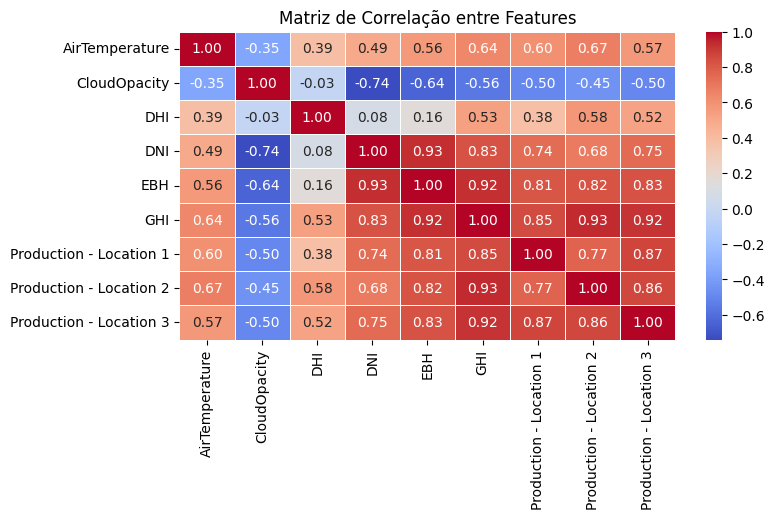

In [25]:
df_heatmap = df_limpo.iloc[:, 1:10]

df_heatmap.info()

correlacao = df_heatmap.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))  # Ajusta o tamanho conforme necessário
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação entre Features")
plt.show()


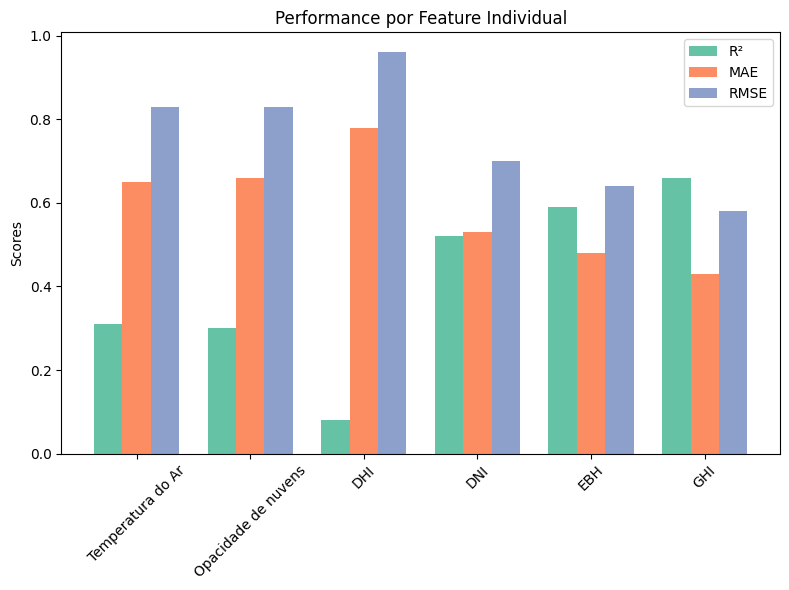

In [28]:
import matplotlib.pyplot as plt
import numpy as np

features = ['Temperatura do Ar', 'Opacidade de nuvens', 'DHI', 'DNI', 'EBH', 'GHI']
r2 = [0.31, 0.30, 0.08, 0.52, 0.59, 0.66]
mae = [0.65, 0.66, 0.78, 0.53, 0.48, 0.43]
rmse = [0.83, 0.83, 0.96, 0.70, 0.64, 0.58]

x = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))
barra1 = ax.bar(x - width, r2, width, label='R²', color='#66C2A5')
barra2 = ax.bar(x, mae, width, label='MAE', color='#FC8D62')
barra3 = ax.bar(x + width, rmse, width, label='RMSE', color='#8DA0CB')

ax.set_ylabel('Scores')
ax.set_title('Performance por Feature Individual')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()